### 1.Load data

In [ ]:
import scanpy as sc # cross celltype predict
import scresid
# import pertpy as pt # download dataset
import warnings
warnings.filterwarnings('ignore')
adata = sc.read_h5ad('./data/bhattacher.h5ad')
adata

AnnData object with n_obs × n_vars = 12936 × 18469
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'percent.mito', 'replicate', 'Period', 'label', 'cell_type', 'subtype'
    var: 'name'

In [ ]:
adata = scresid.adata_process(adata, 
                      # n_top_genes=2000
                      )

In [3]:
adata.obs.rename(columns={"label": "condition"}, inplace=True) # bhattacher
adata.obs["condition"].replace({"Maintenance_Cocaine": "control"}, inplace=True)
adata.obs['condition'].replace({"withdraw_15d_Cocaine": "stimulated"}, inplace=True)
adata.obs['condition'].replace({"withdraw_48h_Cocaine": "stimulated"}, inplace=True)

In [4]:
adata = sc.AnnData(adata.X, obs=adata.obs.copy(), var=adata.var.copy())
adata.obs_names_make_unique()
print(adata)
print('\n', adata.obs['condition'].value_counts())
print('\n', adata.obs['cell_type'].value_counts())

AnnData object with n_obs × n_vars = 12936 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'percent.mito', 'replicate', 'Period', 'condition', 'cell_type', 'subtype', 'n_genes', 'n_counts'
    var: 'name', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'

 condition
stimulated    9960
control       2976
Name: count, dtype: int64

 cell_type
Excitatory    7741
Endo          1708
Oligo          796
Microglia      774
Astro          699
Inhibitory     621
OPC            417
NF Oligo       180
Name: count, dtype: int64


### 2.Build and train models

In [5]:
model = scresid.SCRESID(input_dim=adata.n_vars, device='cuda:0')
model = model.to(model.device)
# key_dic varies with the adata
key_dic = {'condition_key': 'condition',
           'cell_type_key': 'cell_type',
           'ctrl_key': 'control',
           'stim_key': 'stimulated',
           'pred_key': 'predict',
           }


In [ ]:
cell_to_pred = 'Excitatory' # Endo, Oligo, Microglia, Astro, Inhibitory, OPC, NF Oligo
# The training set does not contain the type of data to be predicted after the perturbation
train = adata[~((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
               (adata.obs[key_dic['condition_key']] == key_dic['stim_key']))]
model.train_SCRESID(train, lr=5e-5, epochs=100)

Training Epoch 99: 100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


### 3.Predict

In [7]:
adata_to_pred = adata[((adata.obs[key_dic['cell_type_key']] == cell_to_pred) &
                       (adata.obs[key_dic['condition_key']] == key_dic['ctrl_key']))]
pred = model.predict(train_adata=train,
                     cell_to_pred=cell_to_pred,
                     key_dic=key_dic,
                     ratio=0.005 # The ratio need to vary with the size of dataset
                     )  
print(pred)

Get adata of Excitatory and control...
Get adata of without Excitatory and control...
Get stimulated adata of condition...
Get latent adata of control and stimulated...
Compute distance of stimulated and control by POT...
Compute G of stimulated and control by emd in POT...
Match max idx from G...
Get delta list of matched stimulated and control...
Get latent adata of Excitatory...
Compute cosine similarity with latent adata of Excitatory and control...
Select top control with ratio 0.005...
Normalize weights of 9 top cosine similarity...
Compute delta of predict...
Decode predict latent embedding...
Create predict adata and save key predict...
Predict process completed.
AnnData object with n_obs × n_vars = 1264 × 6000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nGene', 'nUMI', 'percent.mito', 'replicate', 'Period', 'condition', 'cell_type', 'subtype', 'n_genes', 'n_counts'
    var: 'name', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm

### 4.Evaluation

PCA cluster results...


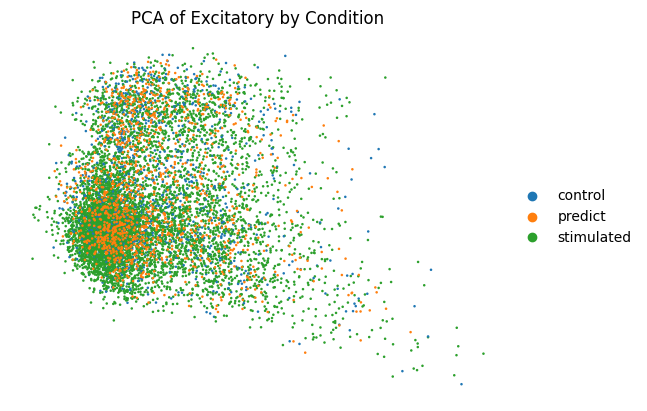

Compute rank_genes_groups...
Select common DEGS...
Common DEGs:  0
Regression plot of mean...


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


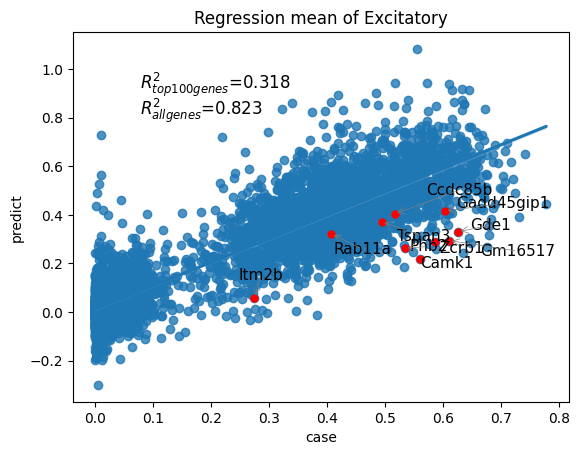

R2 mean of all genes 0.823, top genes 0.318
Regression plot of var...


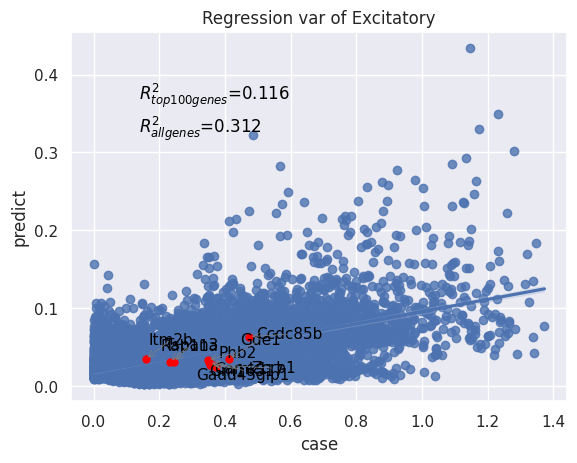

R2 var of all genes 0.312, top genes 0.116
Plot violin graph of first gene Gm16517...


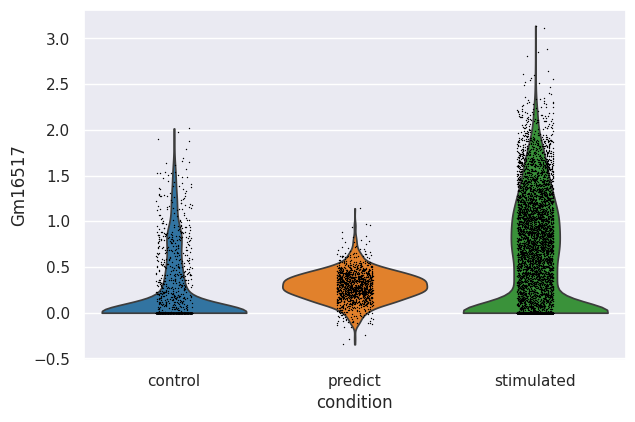

Plot violin graph of second gene Itm2b...


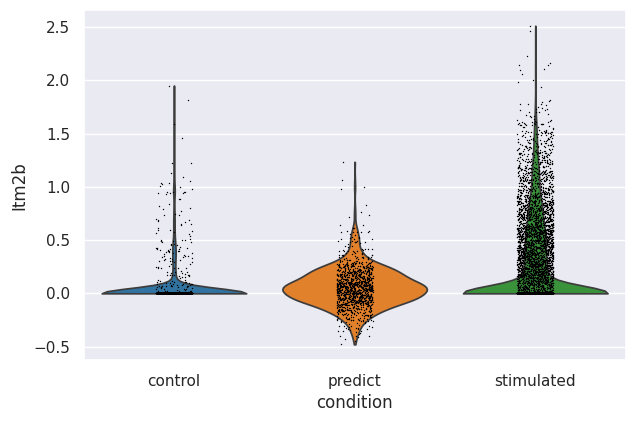

Plot violin graph of third gene Gde1...


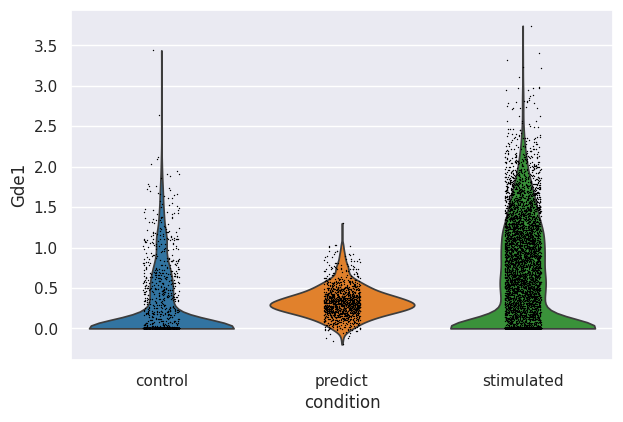

Compute DEGS contrast...
Plot 25 genes of eval_adata...


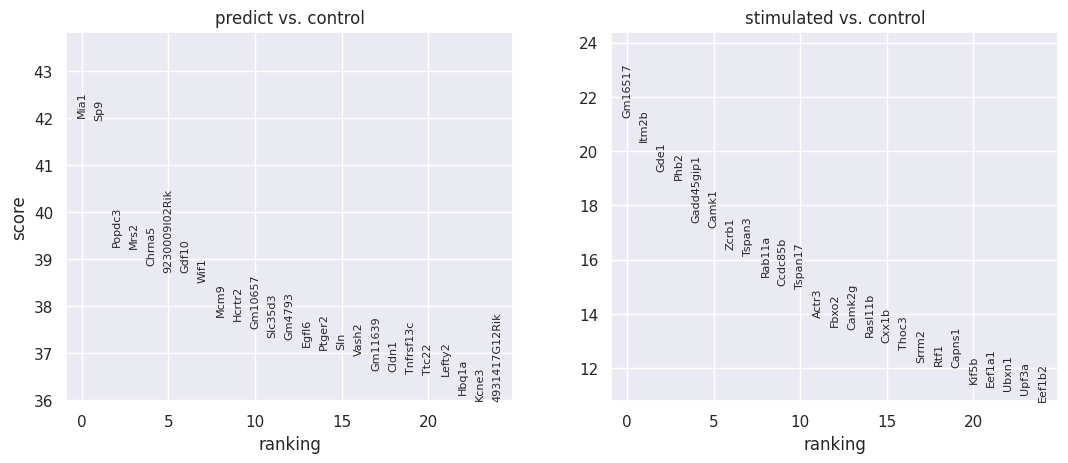

Dotplot of the first 20 genes...


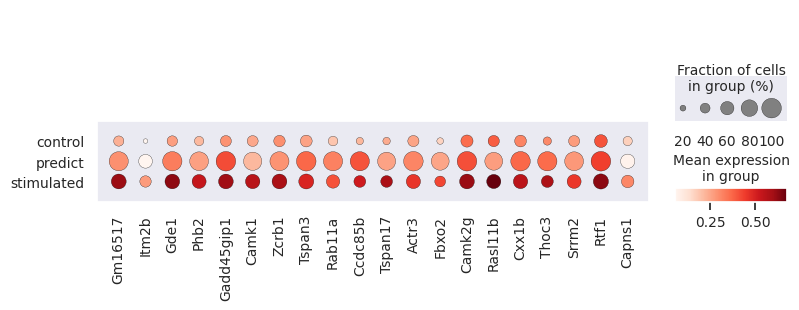

In [8]:
ground_truth = adata[(adata.obs[key_dic['cell_type_key']] == cell_to_pred)]
eval_adata = ground_truth.concatenate(pred)
scresid.evaluate(eval_adata=eval_adata, 
                cell_type=cell_to_pred, 
                key_dic=key_dic
                )
